In [192]:

import matplotlib.pyplot as plt
import json
import os 
# Set project root so relative paths (e.g. routing_performance.json) work
ROOT = "/data/gpfs/projects/punim2662/routing_system"
os.chdir(ROOT)
print(f"Working directory: {os.getcwd()}")

Working directory: /data/gpfs/projects/punim2662/routing_system


In [193]:
import json
with open('performance_data_yi34b_final.json', 'rb') as f:
    data = json.load(f)
print(len(data))


300


# Plot when load and thread percentage varries

In [194]:
failed_rows = []
success_rows = []


for row in data:
    if 'failed' not in row['result']:
        success_rows.append(row)
        # print(row['setup']['tensor_parallel_size'])
    else:
        failed_rows.append(row)

print(f'success rows: {len(success_rows)}')
print(f'failed rows: {len(failed_rows)}')


success rows: 300
failed rows: 0


In [195]:
    # th_load_threshold = 0.99
    # raw_success_rows = success_rows
    # success_rows = [row for row in raw_success_rows if row['result']['performance']['throughput_rps']/row['setup']['load_rps'] > th_load_threshold]

    # print(f'success rows after removing low throughput rows: {len(success_rows)}')




dict_keys(['timestamp', 'config', 'performance', 'ttfts_ms', 'tpot_ms_list', 'metrics_before', 'metrics_after'])
tp: 4, ttft: 2299.037337595694, length: 100
tp: 2, ttft: 3360.63418927251, length: 100
tp: 1, ttft: 8854.433449428798, length: 100
thread: 10, ttft: 15841.140810801002, length: 30
thread: 20, ttft: 11426.735691804402, length: 30
thread: 30, ttft: 6832.8247970358025, length: 30
thread: 40, ttft: 5178.076165133254, length: 30
thread: 50, ttft: 3304.3044863857253, length: 30
thread: 60, ttft: 2042.6921963493337, length: 30
thread: 70, ttft: 1520.9382869120632, length: 30
thread: 80, ttft: 986.9881555982251, length: 30
thread: 90, ttft: 685.6809095199455, length: 30
thread: 100, ttft: 560.9684214502538, length: 30
load: 1.0, ttft: 118.55136754149098, length: 30
load: 3.111111111111111, ttft: 781.1193931648945, length: 30
load: 5.222222222222222, ttft: 1852.6841749357327, length: 30
load: 7.333333333333334, ttft: 3102.153244319915, length: 30
load: 9.444444444444445, ttft: 4289.6

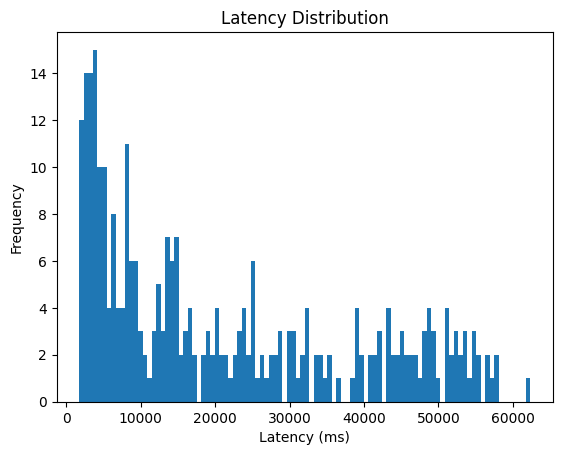

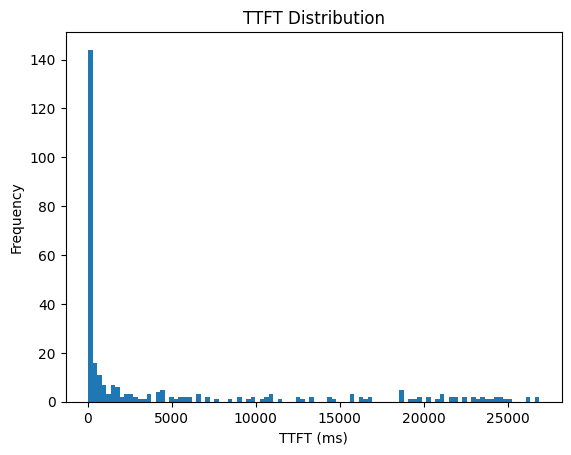

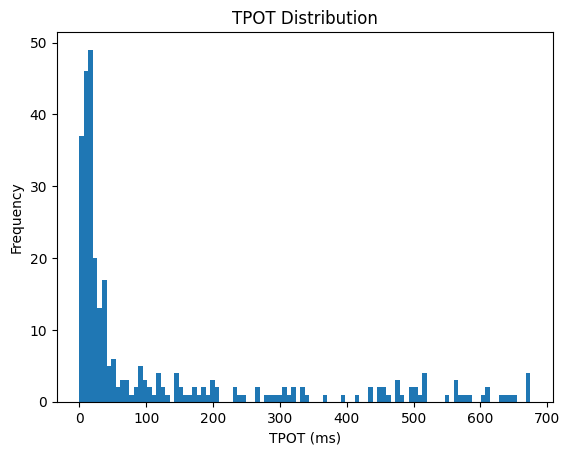

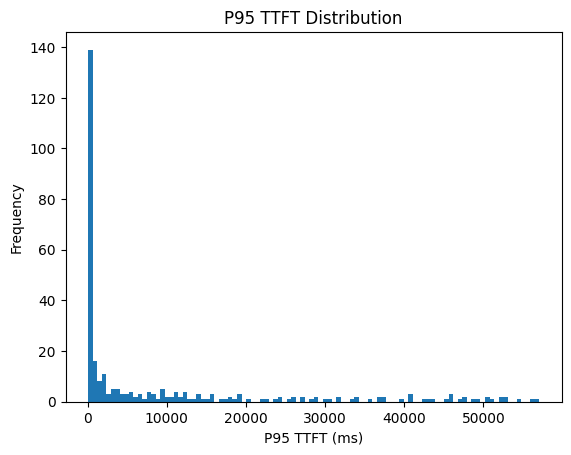

In [196]:
import numpy as np

print(success_rows[0]['result'].keys())
latencies = []
ttfts = []
ttft_per_tp = {}
ttft_per_thread = {}
ttft_per_load = {}
p95_ttfts = []
tpots = []
for row in success_rows:
    latencies.append(row['result']['performance']['p99_latency_ms'])
    ttfts.append(np.mean(row['result']['ttfts_ms']))
    tpots.append(np.mean(row['result']['tpot_ms_list']))
    p95_ttfts.append(np.percentile(row['result']['ttfts_ms'], 95))
    if row['setup']['tensor_parallel_size'] not in ttft_per_tp:
        ttft_per_tp[row['setup']['tensor_parallel_size']] = []
    ttft_per_tp[row['setup']['tensor_parallel_size']].append(np.mean(row['result']['ttfts_ms']))
    if row['setup']['thread_percentage'] not in ttft_per_thread:
        ttft_per_thread[row['setup']['thread_percentage']] = []
    if row['setup']['load_rps'] not in ttft_per_load:
        ttft_per_load[row['setup']['load_rps']] = []
    ttft_per_load[row['setup']['load_rps']].append(np.mean(row['result']['ttfts_ms']))
    ttft_per_thread[row['setup']['thread_percentage']].append(np.mean(row['result']['ttfts_ms']))


for tp in ttft_per_tp:
    print(f'tp: {tp}, ttft: {np.mean(ttft_per_tp[tp])}, length: {len(ttft_per_tp[tp])}')

for thread in ttft_per_thread:
    print(f'thread: {thread}, ttft: {np.mean(ttft_per_thread[thread])}, length: {len(ttft_per_thread[thread])}')

for load in ttft_per_load:
    print(f'load: {load}, ttft: {np.mean(ttft_per_load[load])}, length: {len(ttft_per_load[load])}')

throughput_to_load = []
for row in success_rows:
    throughput_to_load.append(row['result']['performance']['throughput_rps']/row['setup']['load_rps'])
    throughput_to_load.append(np.mean(row['result']['ttfts_ms']))

print(f'ttft: {np.mean(ttfts)}')
print(f'ttft standard deviation: {np.std(ttfts)}')
print(f'tpot: {np.mean(tpots)}')
print(f'tpot standard deviation: {np.std(tpots)}s')



plt.hist(latencies, bins=100)
plt.title('Latency Distribution')
plt.xlabel('Latency (ms)')
plt.ylabel('Frequency')
plt.show()
plt.hist(ttfts, bins=100)
plt.title('TTFT Distribution')
plt.xlabel('TTFT (ms)')
plt.ylabel('Frequency')
plt.show()
plt.hist(tpots, bins=100)
plt.title('TPOT Distribution')
plt.xlabel('TPOT (ms)')
plt.ylabel('Frequency')
plt.show()
plt.hist(p95_ttfts, bins=100)
plt.title('P95 TTFT Distribution')
plt.xlabel('P95 TTFT (ms)')
plt.ylabel('Frequency')
plt.show()